# Probabilistic Queries on Causal Graphs

After discovering a causal graph, we often want to answer probabilistic "what-if" questions:

- **Interventional:** "What if we **set** Mek=5 and PKA=2?" (do-operator, severs incoming edges)
- **Observational:** "Given we **observe** Mek≈5 and PKA≈2, what's the distribution of others?" (conditioning, preserves graph structure)

These give different answers! Interventional queries break the causal mechanisms feeding into the intervened nodes, while observational queries respect the full generative model.

**Features demonstrated:**
1. Interventional queries via `do()`-operator sampling
2. Observational conditioning (soft and hard)
3. Query summaries with weighted percentiles
4. Visualization of conditional distributions
5. Comparing interventional vs observational answers

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts.synthetic_data.synthetic_datasets import ex3
from causalts.effects import wrap_graph, dowhy_available

print('DoWhy available:', dowhy_available())

DoWhy available: True


## 1. Discover Graph and Fit SCM

We use **ex3** (Cascade Network (11-Node)) and discover the graph with CDNOTS.

In [2]:
from causalts import run_cdnots
from causalts.ci_tests import PartialCorr

# Generate data
result = ex3(seed=42, T=500)
df = result['df']
var_names = df.columns.tolist()
print(f'Variables: {var_names}')
print(f'Shape: T={len(df)}, d={df.shape[1]}')

# Discover graph
ci = PartialCorr(data=np.zeros((2, 2)))
_res = run_cdnots(
    df, ci, num_lags=3, include_C=False, alpha=0.05, stable=True
)
disc_graph = _res.cg_tig
cg = _res

# Wrap for the query API
cg_wrap = wrap_graph(disc_graph, df)
print(cg_wrap)

Variables: ['Plcg', 'Pip3', 'Pip2', 'PKC', 'PKA', 'P38', 'Jnk', 'Raf', 'Mek', 'Erk', 'Akt']
Shape: T=500, d=11
WrappedGraph(vars=['Plcg', 'Pip3', 'Pip2', 'PKC', 'PKA', 'P38', 'Jnk', 'Raf', 'Mek', 'Erk', 'Akt'], shape=(11, 11, 4), edges=30)


In [3]:
# Fit the SCM (cached for subsequent queries)
scm, dag, lagged_df = cg_wrap.fit_scm(mechanism_type='linear')
print(f'SCM: {len(dag.nodes)} nodes, {len(dag.edges)} edges')
print(f'Lagged DataFrame: {lagged_df.shape}')

Fitting causal mechanism of node Akt_lag3: 100%|██████████| 44/44 [00:00<00:00, 1580.52it/s]

SCM: 44 nodes, 30 edges
Lagged DataFrame: (497, 44)


## 2. Interventional Query: do(Mek=5, PKA=2)

**"What would happen to other variables if we forcefully SET Mek=5 and PKA=2?"**

This severs all incoming edges to Mek and PKA (their parents no longer affect them) and propagates the fixed values forward through the causal graph.

In [4]:
# Interventional: set Mek and PKA to specific values
intv_samples = cg_wrap.interventional_query(
    intervention={'Mek': 5.0, 'PKA': 2.0},
    n_samples=3000,
)

print(f'Interventional samples: {intv_samples.shape}')
print(f'\nColumns returned (non-intervened variables):')
print(intv_samples.columns.tolist())

# Summary statistics
summary_intv = cg_wrap.query_summary(intv_samples)
print('\n=== Interventional Distribution: do(Mek=5, PKA=2) ===')
print(summary_intv.to_string())

Fitting causal mechanism of node Akt_lag3: 100%|██████████| 44/44 [00:00<00:00, 1467.80it/s]

Interventional samples: (3000, 42)

Columns returned (non-intervened variables):
['Plcg_lag1', 'Pip3_lag1', 'Pip2_lag1', 'PKC_lag1', 'PKA_lag1', 'P38_lag1', 'Jnk_lag1', 'Raf_lag1', 'Mek_lag1', 'Erk_lag1', 'Akt_lag1', 'Plcg_lag2', 'Pip3_lag2', 'Pip2_lag2', 'PKC_lag2', 'PKA_lag2', 'P38_lag2', 'Jnk_lag2', 'Raf_lag2', 'Mek_lag2', 'Erk_lag2', 'Akt_lag2', 'Plcg_lag3', 'Pip3_lag3', 'Pip2_lag3', 'PKC_lag3', 'PKA_lag3', 'P38_lag3', 'Jnk_lag3', 'Raf_lag3', 'Mek_lag3', 'Erk_lag3', 'Akt_lag3', 'PKC', 'Pip3', 'Raf', 'P38', 'Erk', 'Akt', 'Pip2', 'Jnk', 'Plcg']

=== Interventional Distribution: do(Mek=5, PKA=2) ===
               mean       std       p05       p25       p50       p75       p95
variable                                                                       
Plcg_lag1  0.198680  2.327510 -3.553293 -1.283397  0.071516  1.658947  4.106069
Pip3_lag1  0.240832  2.918762 -4.266672 -1.662316 -0.062933  2.289532  4.886859
Pip2_lag1  0.305719  3.083634 -4.765230 -1.772821  0.255381  2.368394  5

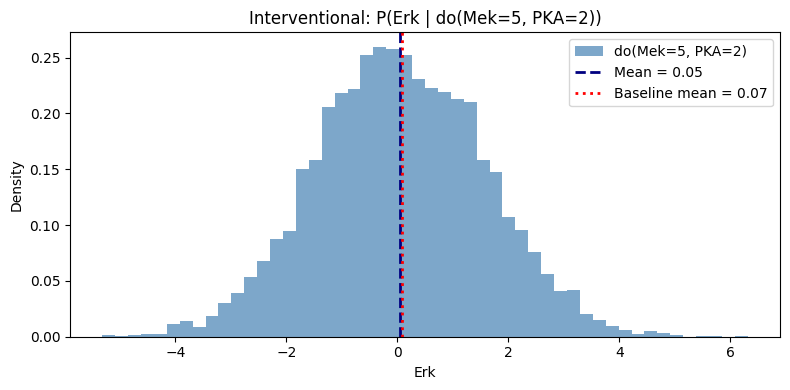

In [5]:
# Query a specific target
intv_erk = cg_wrap.interventional_query(
    intervention={'Mek': 5.0, 'PKA': 2.0},
    targets='Erk',
    n_samples=5000,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(intv_erk['Erk'], bins=50, density=True, alpha=0.7, color='steelblue',
        label='do(Mek=5, PKA=2)')
ax.axvline(intv_erk['Erk'].mean(), color='navy', ls='--', lw=2,
           label=f'Mean = {intv_erk["Erk"].mean():.2f}')
ax.axvline(lagged_df['Erk'].mean(), color='red', ls=':', lw=2,
           label=f'Baseline mean = {lagged_df["Erk"].mean():.2f}')
ax.set_xlabel('Erk'); ax.set_ylabel('Density')
ax.set_title('Interventional: P(Erk | do(Mek=5, PKA=2))')
ax.legend()
plt.tight_layout(); plt.show()

## 3. Observational Query: P(others | Mek≈5, PKA≈2)

**"Given that we observe Mek≈5 and PKA≈2, what's the likely distribution of other variables?"**

Unlike the interventional query, this preserves the full causal structure — it conditions rather than intervenes. This means the parents of Mek and PKA are also likely to have specific values (the ones that would have produced Mek≈5 and PKA≈2).

Two conditioning modes:
- **Soft** (default): Gaussian kernel weighting — samples near the evidence get higher weight
- **Hard** (`tolerance=...`): Rejection sampling — only keeps exact matches (within tolerance)

In [6]:
# Soft conditioning (default) — Gaussian kernel weighting
obs_samples = cg_wrap.observational_query(
    evidence={'Mek': 5.0, 'PKA': 2.0},
    n_samples=10000,
)

print(f'Observational samples: {obs_samples.shape}')
print(f'Has weights: {"_weight" in obs_samples.columns}')
print(f'Effective sample size: {1 / (obs_samples["_weight"]**2).sum():.0f}')

# Summary
summary_obs = cg_wrap.query_summary(obs_samples)
print('\n=== Observational Distribution: P(· | Mek≈5, PKA≈2) ===')
print(summary_obs.to_string())

Observational samples: (10000, 43)
Has weights: True
Effective sample size: 41

=== Observational Distribution: P(· | Mek≈5, PKA≈2) ===
               mean       std       p05       p25       p50       p75       p95
variable                                                                       
Plcg_lag1  0.057061  2.095707 -4.993504 -1.334100  0.378329  1.040249  3.573625
Pip3_lag1  0.149677  2.298304 -3.482694 -1.434965 -0.151705  1.859364  3.845972
Pip2_lag1  0.134574  3.574572 -8.360426 -1.843559  1.182934  2.472808  4.470075
PKC_lag1  -0.923650  0.972774 -2.519636 -1.584848 -0.984278 -0.134864  0.494840
PKA_lag1   0.335968  0.774512 -0.796832 -0.294915  0.531153  0.868313  1.400370
P38_lag1   0.129765  1.722216 -2.467198 -1.115773  0.165211  1.357786  3.710224
Jnk_lag1  -0.130601  1.229329 -2.573187 -0.871222 -0.265130  0.873949  1.939654
Raf_lag1  -0.141541  1.082134 -2.208965 -0.762603  0.168520  0.736414  1.263119
Mek_lag1   2.524850  1.714415  0.012923  1.224059  2.230166  3.5

In [7]:
# Hard conditioning with tolerance — rejection sampling
obs_hard = cg_wrap.observational_query(
    evidence={'Mek': 5.0, 'PKA': 2.0},
    n_samples=50000,  # more raw samples needed for rejection
    tolerance=1.0,    # accept if within 1 std of target
)

print(f'Hard conditioning: {len(obs_hard)} samples accepted out of 50000')
print(f'Acceptance rate: {len(obs_hard)/50000:.1%}')

summary_hard = cg_wrap.query_summary(obs_hard)
print('\n=== Hard conditioning: P(· | |Mek-5|<1σ, |PKA-2|<1σ) ===')
print(summary_hard.to_string())

Hard conditioning: 170 samples accepted out of 50000
Acceptance rate: 0.3%

=== Hard conditioning: P(· | |Mek-5|<1σ, |PKA-2|<1σ) ===
               mean       std       p05       p25       p50       p75       p95
variable                                                                       
Plcg_lag1  0.009511  2.340267 -3.531350 -1.486498 -0.088575  1.491734  3.928200
Pip3_lag1  0.140372  2.748778 -3.717476 -1.709902 -0.408617  1.877916  4.730783
Pip2_lag1  0.333615  3.040698 -4.392550 -1.643010  0.337590  2.347011  5.543376
PKC_lag1  -1.043915  1.007378 -2.584678 -1.619748 -1.032916 -0.365976  0.515895
PKA_lag1   0.405896  0.909035 -0.911856 -0.292457  0.400195  1.052485  1.773780
P38_lag1  -0.156153  1.262741 -2.160192 -1.066837 -0.062991  0.692580  1.751273
Jnk_lag1   0.036630  1.164563 -2.012216 -0.750012  0.047375  0.847010  1.770795
Raf_lag1   0.065333  1.147345 -1.735618 -0.762603  0.120935  0.773534  1.900864
Mek_lag1   2.758899  1.721534  0.168432  1.702897  2.450816  3.3995

## 4. Comparing Interventional vs Observational

The key insight: interventional and observational queries give **different answers** because they imply different things about the state of the system.

- **Interventional** (do): We *force* Mek=5 regardless of what would naturally produce that value. Parents of Mek are unaffected.
- **Observational** (see): We *observe* Mek≈5, which implies something about its causes — the parents probably had values that would generate Mek≈5.

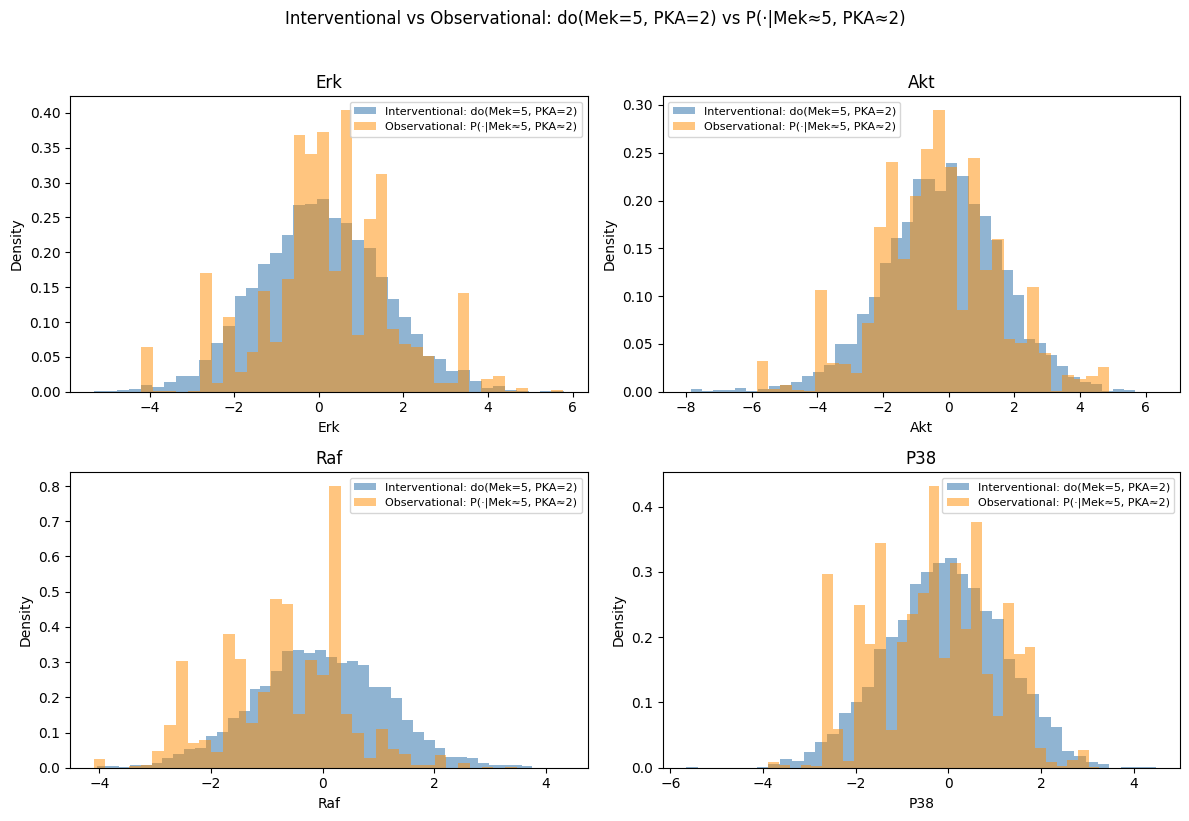

In [ ]:
# Compare distributions for key downstream variables
targets_to_compare = ['Erk', 'Akt', 'Raf', 'P38']

# Interventional samples
intv_all = cg_wrap.interventional_query(
    intervention={'Mek': 5.0, 'PKA': 2.0},
    targets=targets_to_compare,
    n_samples=5000,
)

# Observational samples (soft)
obs_all = cg_wrap.observational_query(
    evidence={'Mek': 5.0, 'PKA': 2.0},
    targets=targets_to_compare,
    n_samples=20000,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.flat, targets_to_compare):
    # Interventional
    ax.hist(intv_all[var], bins=40, density=True, alpha=0.6,
            color='steelblue', label='Interventional: do(Mek=5, PKA=2)')

    # Observational (weighted histogram)
    weights = obs_all['_weight'].values
    ax.hist(obs_all[var], bins=40, density=True, alpha=0.5,
            weights=weights, color='darkorange',
            label='Observational: P(·|Mek≈5, PKA≈2)')

    ax.set_xlabel(var)
    ax.set_ylabel('Density')
    ax.set_title(var)
    ax.legend(fontsize=8)

plt.suptitle('Interventional vs Observational: do(Mek=5, PKA=2) vs P(·|Mek≈5, PKA≈2)',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

In [9]:
# Side-by-side summary table
sum_intv = cg_wrap.query_summary(intv_all)
sum_obs = cg_wrap.query_summary(obs_all)

comparison = pd.DataFrame({
    'Intv. mean': sum_intv['mean'],
    'Intv. std': sum_intv['std'],
    'Obs. mean': sum_obs['mean'],
    'Obs. std': sum_obs['std'],
    'Mean diff': sum_obs['mean'] - sum_intv['mean'],
})
print('=== Comparison: Interventional vs Observational ===')
print(comparison.round(3).to_string())
print('\nPositive "Mean diff" = observational expects higher values than interventional.')
print('This happens when observing Mek≈5 implies its parents were high,')
print('which also affects downstream variables through other paths.')

=== Comparison: Interventional vs Observational ===
          Intv. mean  Intv. std  Obs. mean  Obs. std  Mean diff
variable                                                       
Erk            0.052      1.493      0.229     1.554      0.177
Akt           -0.178      1.782     -0.347     1.850     -0.169
Raf           -0.054      1.172     -0.704     1.112     -0.650
P38           -0.084      1.259     -0.318     1.302     -0.234

Positive "Mean diff" = observational expects higher values than interventional.
This happens when observing Mek≈5 implies its parents were high,
which also affects downstream variables through other paths.


## 5. Single-Variable Query with Visualization

A common use case: "Given that PKC is high, what's the distribution of Mek?"

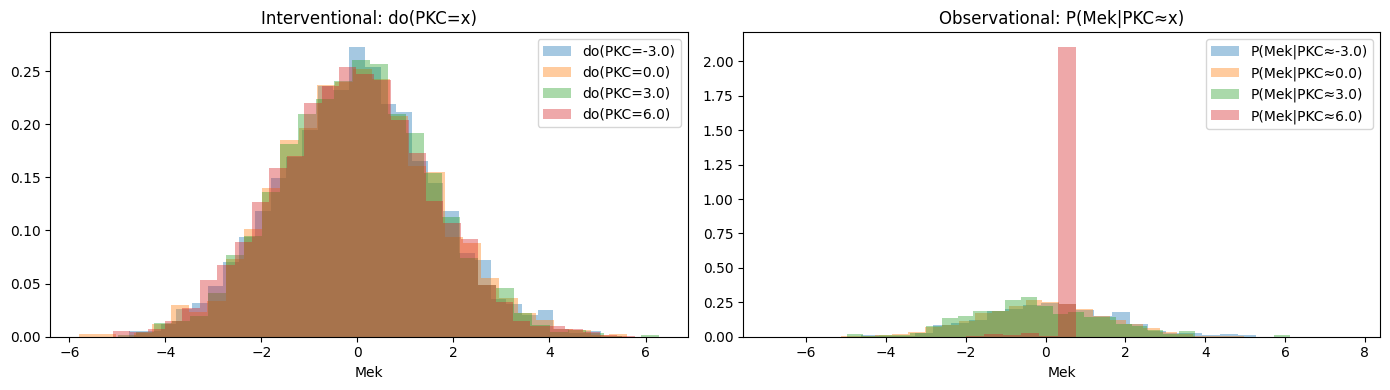

Left: changing the intervention shifts the Mek distribution (causal effect).
Right: conditioning on PKC also shifts Mek but may differ due to confounders.


In [ ]:
# What happens to Mek under different PKC values?
pkc_values = [-3.0, 0.0, 3.0, 6.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for pkc_val in pkc_values:
    # Interventional
    s_intv = cg_wrap.interventional_query(
        intervention={'PKC': pkc_val}, targets='Mek', n_samples=3000
    )
    axes[0].hist(s_intv['Mek'], bins=30, density=True, alpha=0.4,
                label=f'do(PKC={pkc_val})')

    # Observational
    s_obs = cg_wrap.observational_query(
        evidence={'PKC': pkc_val}, targets=['Mek'], n_samples=10000
    )
    axes[1].hist(s_obs['Mek'], bins=30, density=True, alpha=0.4,
                weights=s_obs['_weight'],
                label=f'P(Mek|PKC≈{pkc_val})')

axes[0].set_title('Interventional: do(PKC=x)')
axes[0].set_xlabel('Mek'); axes[0].legend()
axes[1].set_title('Observational: P(Mek|PKC≈x)')
axes[1].set_xlabel('Mek'); axes[1].legend()

plt.tight_layout(); plt.show()
print('Left: changing the intervention shifts the Mek distribution (causal effect).')
print('Right: conditioning on PKC also shifts Mek but may differ due to confounders.')

## 6. Controlling Kernel Bandwidth

The `kernel_bandwidth` parameter controls how "soft" the conditioning is:
- **Small bandwidth** (e.g., 0.1): Very tight conditioning, effectively hard matching
- **Large bandwidth** (e.g., 2.0): Very soft, includes samples far from the evidence
- **Default** (0.5): Balanced — weights drop off at ~1 std from the evidence

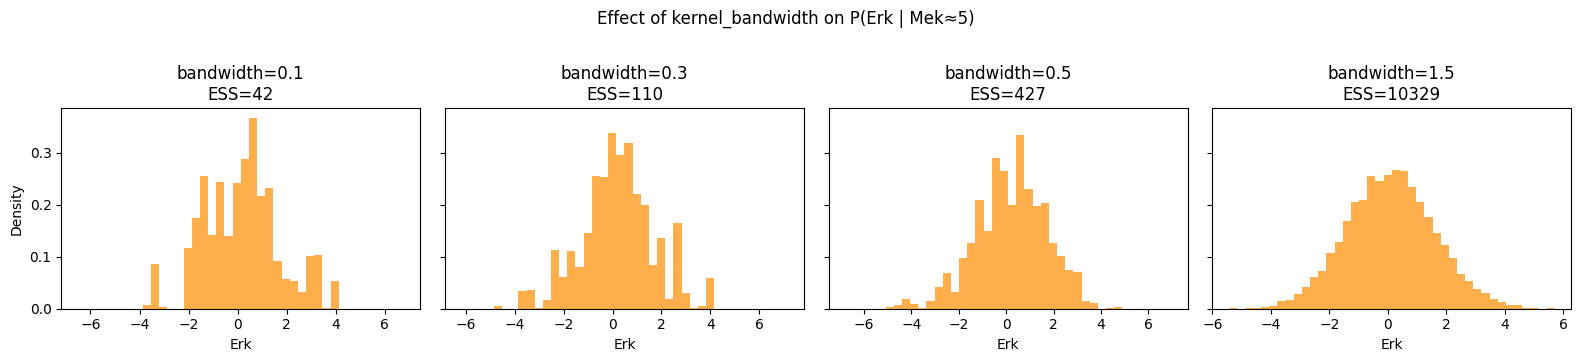

Smaller bandwidth = sharper conditioning (fewer effective samples).
Larger bandwidth = softer conditioning (more samples contribute).


In [11]:
bandwidths = [0.1, 0.3, 0.5, 1.5]

fig, axes = plt.subplots(1, len(bandwidths), figsize=(16, 3.5), sharey=True)

for ax, bw in zip(axes, bandwidths):
    s = cg_wrap.observational_query(
        evidence={'Mek': 5.0},
        targets=['Erk'],
        n_samples=20000,
        kernel_bandwidth=bw,
    )
    ess = 1 / (s['_weight']**2).sum()
    ax.hist(s['Erk'], bins=40, density=True, weights=s['_weight'],
            alpha=0.7, color='darkorange')
    ax.set_title(f'bandwidth={bw}\nESS={ess:.0f}')
    ax.set_xlabel('Erk')

axes[0].set_ylabel('Density')
plt.suptitle('Effect of kernel_bandwidth on P(Erk | Mek≈5)', y=1.02)
plt.tight_layout(); plt.show()
print('Smaller bandwidth = sharper conditioning (fewer effective samples).')
print('Larger bandwidth = softer conditioning (more samples contribute).')

## 7. Using the Standalone API

The query functions are also available as standalone functions (not just via `WrappedGraph`):

In [12]:
from causalts.effects import interventional_query, observational_query, query_summary
from causalts.effects import fit_scm

# Standalone usage
scm, dag, lagged_df = fit_scm(disc_graph, df, mechanism_type='linear')

# Interventional
samples = interventional_query(scm, {'Mek': 5.0}, targets=['Erk', 'Akt'], n_samples=2000)
print('Interventional query (standalone):')
print(query_summary(samples).round(3))

print()

# Observational
samples = observational_query(scm, lagged_df, {'Mek': 5.0}, targets=['Erk', 'Akt'])
print('Observational query (standalone):')
print(query_summary(samples).round(3))

Fitting causal mechanism of node Akt_lag3: 100%|██████████| 44/44 [00:00<00:00, 2045.57it/s]

Interventional query (standalone):
           mean    std    p05    p25    p50    p75    p95
variable                                                 
Erk       0.059  1.515 -2.510 -0.913  0.035  1.055  2.575
Akt      -0.163  1.796 -3.141 -1.313 -0.114  1.050  2.721

Observational query (standalone):
           mean    std    p05    p25    p50    p75    p95
variable                                                 
Erk       0.207  1.381 -2.102 -0.690  0.235  1.078  2.430
Akt      -0.343  1.679 -3.232 -1.471 -0.176  0.868  2.246


## Summary

| Query type | Method | What it answers | Edges severed? |
|---|---|---|---|
| Interventional | `interventional_query()` | "What if we SET X=x?" | Yes (do-operator) |
| Observational (soft) | `observational_query()` | "Given we see X≈x, what's Y?" | No |
| Observational (hard) | `observational_query(tolerance=...)` | "Given X is near x, what's Y?" | No |

**Key API:**
```python
# Via WrappedGraph
cg = wrap_graph(G_hat, df)
cg.interventional_query({'Mek': 5.0, 'PKA': 2.0}, targets='Erk')
cg.observational_query({'Mek': 5.0, 'PKA': 2.0}, targets='Erk')
cg.query_summary(samples)

# Standalone
from causalts.effects import interventional_query, observational_query, query_summary
interventional_query(scm, intervention, targets, n_samples)
observational_query(scm, lagged_df, evidence, targets, tolerance, kernel_bandwidth)
query_summary(result)
```